In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Librería para el balanceo (SMOTE)
from imblearn.over_sampling import SMOTE

print("✅ Librerías listas para el Pipeline.")

✅ Librerías listas para el Pipeline.


In [2]:
# Cargamos el archivo que Iris dejó limpio
# Nos aseguramos de que el nombre coincide con el que hay en data/processed/
df = pd.read_csv("../data/processed/nhanes_clean.csv")

print(f"Dataset cargado correctamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Dataset cargado correctamente: 9074 filas y 24 columnas.


,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,nivel_pobreza_familiar,ui_frecuencia,...,ui_molestia_percibida,ui_impacto_actividades,target_tipo_ui,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
0,29.0,37.8,0.0,0.0,0.0,0.0,0.0,1,3.0,1,...,1,1,none,0,0,0,0,1,1,0
1,21.0,30.2,0.0,0.0,0.0,0.0,0.0,1,3.0,1,...,2,1,none,0,0,1,0,0,1,0
2,44.0,39.1,0.0,0.0,0.0,0.0,0.0,0,2.4,4,...,2,2,stress,0,1,0,0,0,1,0
3,33.0,28.9,0.0,0.0,0.0,0.0,0.0,0,1.0,2,...,1,1,none,0,0,0,0,1,1,0
4,68.0,28.1,1.0,1.0,0.0,1.0,0.0,0,3.0,3,...,2,1,urge,0,0,0,1,0,0,1


In [3]:
# Separamos Features (X) y Target (y)
X = df.drop(columns=['target_tipo_ui'])
y = df['target_tipo_ui']

# Hacemos el split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y # <-- Esto garantiza que el % de enfermedad sea igual en ambos
)

# Comprobación de proporciones
print("Proporción de clases en el set de ENTRENAMIENTO:")
print(y_train.value_counts(normalize=True) * 100)

print("\nProporción de clases en el set de TEST:")
print(y_test.value_counts(normalize=True) * 100)

Proporción de clases en el set de ENTRENAMIENTO:
target_tipo_ui
none      53.519769
mixed     18.101667
stress    17.481747
urge      10.896818
Name: proportion, dtype: float64

Proporción de clases en el set de TEST:
target_tipo_ui
none      53.553719
mixed     18.071625
stress    17.465565
urge      10.909091
Name: proportion, dtype: float64


## Pipeline de Preprocesamiento (Issue #5)

En esta fase, preparamos los datos para el entrenamiento de modelos de Machine Learning, asegurando que el proceso sea reproducible y libre de sesgos.

### División del Dataset (Train/Test Split)
Para evaluar correctamente el rendimiento de nuestros modelos, dividimos los datos en dos conjuntos:
* **Entrenamiento (80%):** Datos con los que los modelos aprenderán los patrones.
* **Prueba (20%):** Datos "ciegos" que utilizaremos para validar la capacidad de predicción real.

> **Decisión Técnica (Estratificación):** Se utiliza el parámetro `stratify=y`. Dado que la clase de "urgencia" es minoritaria (aprox. 10.3%), la estratificación garantiza que tanto el set de entrenamiento como el de prueba mantengan la misma proporción de casos de UI, evitando que el modelo sea evaluado en un escenario no representativo.

### Ingeniería de Características (Scaling)
Las variables como la `edad` y el `indice_masa_corporal` tienen rangos numéricos muy distintos. 
* **Técnica:** Se aplica `StandardScaler` para normalizar los datos.
* **Prevención de Data Leakage:** El escalador se entrena (`fit`) exclusivamente con los datos de entrenamiento y solo se aplica (`transform`) al conjunto de prueba. Esto garantiza que la información del "examen" no contamine el aprendizaje del modelo.

In [4]:
# 1. Instanciamos el escalador
scaler = StandardScaler()

# 2. ENTRENAMOS y TRANSFORMAMOS el set de entrenamiento
# El escalador "aprende" la media y var de X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. SOLO TRANSFORMAMOS el set de test
# Usamos lo aprendido en train para escalar el test (sin mirar sus datos)
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para que sea más fácil de ver (opcional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("✅ Escalado completado.")
X_train_scaled_df.head()

✅ Escalado completado.


,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,nivel_pobreza_familiar,ui_frecuencia,...,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
0,0.069578,0.547882,1.295607,2.541738,2.561534,1.357690,1.389872,2.078905,0.908731,2.156357,...,3.034726,2.238423,2.145812,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
1,1.503442,-0.080450,1.295607,-0.393432,-0.390391,1.357690,1.389872,-0.481022,-0.046168,-0.153253,...,-0.329519,-0.000771,-0.656464,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
2,0.815187,-0.059330,1.295607,-0.393432,-0.390391,-0.736545,-0.719491,-0.481022,-0.046168,-0.153253,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,1.738277,-1.738277
3,0.241641,2.554324,1.295607,-0.393432,-0.390391,1.357690,-0.719491,-0.481022,0.908731,2.156357,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282
4,-0.217195,0.772287,1.295607,-0.393432,-0.390391,-0.736545,1.389872,-0.481022,-1.478517,-0.923123,...,-0.329519,-1.120368,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282


Distribución de clases DESPUÉS de SMOTE:
target_tipo_ui
mixed     25.0
none      25.0
urge      25.0
stress    25.0
Name: proportion, dtype: float64


<Axes: title={'center': 'Distribución de clases (SMOTE)'}, xlabel='target_tipo_ui'>

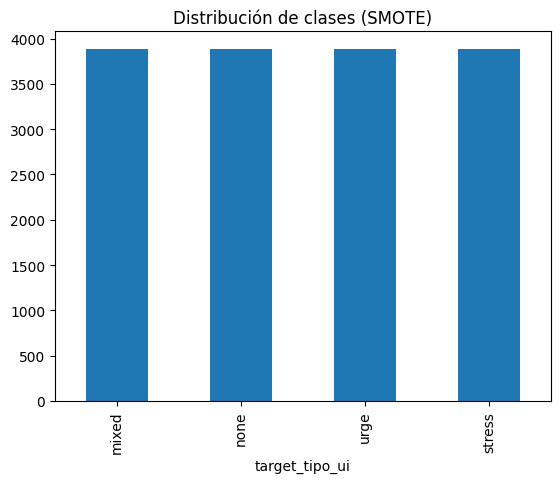

In [5]:
# 1. Configuramos SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicamos SOLO en el set de entrenamiento escalado
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 3. Comprobamos el nuevo balanceo
print("Distribución de clases DESPUÉS de SMOTE:")
print(y_train_res.value_counts(normalize=True) * 100)

# Visualización rápida
y_train_res.value_counts().plot(kind='bar', title='Distribución de clases (SMOTE)')

In [6]:
# Convertimos los arrays de numpy resultantes de SMOTE y el escalado a DataFrames de Pandas
# Esto los mantiene en la memoria RAM listos para usar

# Set de Entrenamiento (Escalado + SMOTE)
X_train_final = pd.DataFrame(X_train_res, columns=X.columns)
y_train_final = y_train_res

# Set de Test (Escalado, datos reales)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)
y_test_final = y_test

print("✅ Todos los datasets han sido creados y están guardados en memoria.")
print(f"Dimensiones de X_train_final: {X_train_final.shape}")
print(f"Dimensiones de X_test_final: {X_test_final.shape}")

# Mostramos un adelanto de los datos listos para el modelo
X_train_final.head()

✅ Todos los datasets han sido creados y están guardados en memoria.
Dimensiones de X_train_final: (15540, 23)
Dimensiones de X_test_final: (1815, 23)


,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,nivel_pobreza_familiar,ui_frecuencia,...,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
0,0.069578,0.547882,1.295607,2.541738,2.561534,1.357690,1.389872,2.078905,0.908731,2.156357,...,3.034726,2.238423,2.145812,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
1,1.503442,-0.080450,1.295607,-0.393432,-0.390391,1.357690,1.389872,-0.481022,-0.046168,-0.153253,...,-0.329519,-0.000771,-0.656464,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
2,0.815187,-0.059330,1.295607,-0.393432,-0.390391,-0.736545,-0.719491,-0.481022,-0.046168,-0.153253,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,1.738277,-1.738277
3,0.241641,2.554324,1.295607,-0.393432,-0.390391,1.357690,-0.719491,-0.481022,0.908731,2.156357,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282
4,-0.217195,0.772287,1.295607,-0.393432,-0.390391,-0.736545,1.389872,-0.481022,-1.478517,-0.923123,...,-0.329519,-1.120368,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282


In [7]:
# Verificación de la integridad de los datos finales
# Usamos la primera columna disponible para la prueba de media
columna_prueba = X_train_final.columns[0] 

verificacion = pd.DataFrame({
    'Set': ['X_train_final', 'X_test_final'],
    'Registros': [X_train_final.shape[0], X_test_final.shape[0]],
    'Nulos': [X_train_final.isnull().sum().sum(), X_test_final.isnull().sum().sum()],
    'Media_Columna_Escalada': [
        X_train_final[columna_prueba].mean().round(4), 
        X_test_final[columna_prueba].mean().round(4)
    ]
})

print(f"📊 RESUMEN DE CALIDAD (Columna analizada: {columna_prueba})")
display(verificacion)

📊 RESUMEN DE CALIDAD (Columna analizada: edad_anios)


,Set,Registros,Nulos,Media_Columna_Escalada
0,X_train_final,15540,0,0.1089
1,X_test_final,1815,0,0.0136


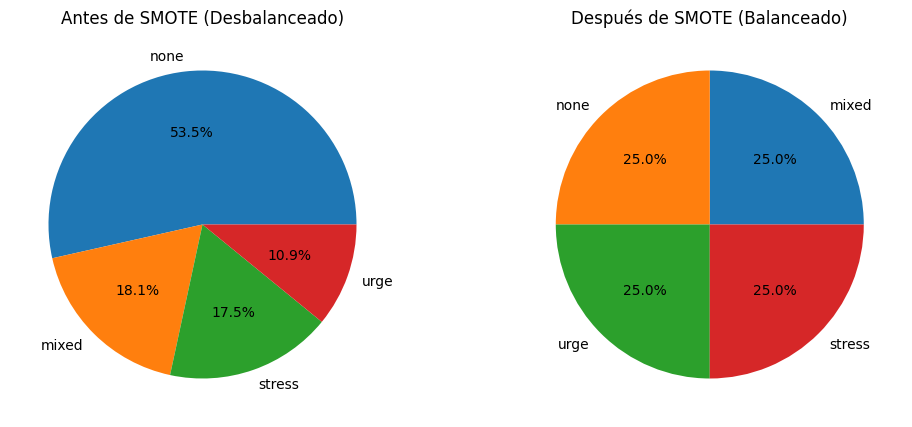

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Antes del SMOTE (y_train original)
y_train.value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0], title='Antes de SMOTE (Desbalanceado)')

# Después del SMOTE (y_train_res)
y_train_res.value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1], title='Después de SMOTE (Balanceado)')

plt.show()

## Consolidación de Datasets en Memoria
Para optimizar el flujo de trabajo en el entorno de desarrollo, se han consolidado los resultados del preprocesamiento en objetos de memoria (`DataFrames`). 

* **X_train_final / y_train_final:** Contienen las características escaladas y balanceadas mediante SMOTE. Es el set que se utilizará para el entrenamiento de los algoritmos de clasificación.
* **X_test_final / y_test_final:** Contienen los datos de validación escalados con los parámetros de entrenamiento, garantizando una evaluación justa del rendimiento.

Esta aproximación permite una transición inmediata a la fase de modelado sin latencia de lectura/escritura en disco.

In [9]:
X_train_final.isnull().sum().sum()

np.int64(0)

In [10]:
# 1. Renombrado profesional (Verifica que el nombre original coincida con el de Iris)
col_original = 'ind_poverty_level' 

if col_original in X_train_final.columns:
    X_train_final = X_train_final.rename(columns={col_original: 'economic_status'})
    X_test_final = X_test_final.rename(columns={col_original: 'economic_status'})
    print(f"✅ Variable '{col_original}' renombrada a 'economic_status'.")

# 2. Definición de rutas según tu imagen
# ../../ sube dos niveles: de 'modeling' a 'notebooks' y de 'notebooks' a la raíz
path_models = "../models/"
path_data_processed = "../data/processed/"

# Creamos las carpetas si no existen
os.makedirs(path_models, exist_ok=True)
os.makedirs(path_data_processed, exist_ok=True)

# 3. Guardado en el directorio 'models' con extensión .pkl
joblib.dump(scaler, os.path.join(path_models, "pipeline.pkl"))
print(f"✅ Archivo guardado en: {os.path.abspath(os.path.join(path_models, 'pipeline.pkl'))}")

# 4. Guardado de datasets
X_train_final.to_csv(os.path.join(path_data_processed, "X_train_final.csv"), index=False)
y_train_final.to_csv(os.path.join(path_data_processed, "y_train_final.csv"), index=False)
X_test_final.to_csv(os.path.join(path_data_processed, "X_test_final.csv"), index=False)
y_test_final.to_csv(os.path.join(path_data_processed, "y_test_final.csv"), index=False)

print(f"✅ Datasets exportados a: {path_data_processed}")

✅ Archivo guardado en: c:\Users\SONY VAIO\desktop\ia\practicas\proyecto7_Equipo3_Multiclase\models\pipeline.pkl
✅ Datasets exportados a: ../data/processed/


## 💾 Persistencia y Exportación del Pipeline

Para garantizar que el preprocesamiento sea reproducible en la fase de modelado y en la futura aplicación web, **hemos procedido** a:

1. **Estandarización de Variables:** Se ha renombrado el índice de pobreza a `economic_status` para mejorar la interpretabilidad técnica.
2. **Serialización del Escalador:** Se guarda el objeto `StandardScaler` como `pipeline.pkl` en la carpeta `/models/`. Esto es crítico para escalar correctamente los nuevos datos de entrada en producción.
3. **Exportación de Datasets:** Se generan archivos CSV con los datos finales (ya escalados y balanceados con SMOTE) para que el equipo de ciencia de datos pueda iniciar el entrenamiento de modelos de forma inmediata.

Con este paso, el **Pipeline de Preprocesamiento** queda oficialmente cerrado y listo para su integración.